In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the datasets
complaints_df = pd.read_csv("311_compliants.csv")
baskets_df = pd.read_csv("DSNY_Litter_Basket_Inventory.csv")
tonnage_df = pd.read_csv("../tonnage/DSNY_Monthly_Tonnage_Data_20251117.csv")
population_df = pd.read_csv("../tonnage/New_York_City_Population_By_Community_Districts_20251123.csv")
pedestrian_df = pd.read_csv("Pedestrian_Counts_Annual_With_Community_Districts.csv")

print("=== 311 Complaints Data ===")
print(complaints_df.info())
print(complaints_df.head())

print("\n\n=== DSNY Litter Basket Inventory Data ===")
print(baskets_df.info())
print(baskets_df.head())

print("\n\n=== DSNY Monthly Tonnage Data ===")
print(tonnage_df.info())
print(tonnage_df.head())

print("\n\n=== NYC Population Data ===")
print(population_df.info())
print(population_df.head())

print("\n\n=== Bi-Annual Pedestrain Counts Data ===")
print(pedestrian_df.info())
print(pedestrian_df.head())


=== 311 Complaints Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97966 entries, 0 to 97965
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year_month       97966 non-null  object
 1   NTA2020          97966 non-null  object
 2   Complaint Type   97966 non-null  object
 3   complaint_count  97966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 3.0+ MB
None
  year_month NTA2020                     Complaint Type  complaint_count
0    2010-01  BK0101            Litter Basket / Request                2
1    2010-01  BK0101  Missed Collection (All Materials)               13
2    2010-01  BK0102            Litter Basket / Request                4
3    2010-01  BK0102  Missed Collection (All Materials)               14
4    2010-01  BK0102         Sweeping/Missed-Inadequate                3


=== DSNY Litter Basket Inventory Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24681 e

In [78]:
#standardize Community District IDs
def get_standard_cd(row, source):
    if source == 'tonnage':
        b_map = {'Manhattan': 'MN', 'Bronx': 'BX', 'Brooklyn': 'BK', 'Queens': 'QN', 'Staten Island': 'SI'}
        b = b_map.get(row['BOROUGH'].strip(), None)
        if b is None: 
            return None
        cd = int(row['COMMUNITYDISTRICT'])
        return f"{b}{cd:02d}"
    elif source == 'population':
        b_map = {'Manhattan': 'MN', 'Bronx': 'BX', 'Brooklyn': 'BK', 'Queens': 'QN', 'Staten Island': 'SI'}
        b = b_map.get(row['Borough'].strip(), None)
        cd = int(row['CD Number'])
        return f"{b}{cd:02d}"
    elif source == 'basket':
        s = str(row['SECTION']).strip()
        if s.startswith('BKN') or s.startswith('BKS'): 
            return f"BK{s[3:5]}"
        if s.startswith('QE') or s.startswith('QW'): 
            return f"QN{s[2:4]}"
        if s.startswith('MN'): return f"MN{s[2:4]}"
        if s.startswith('BX'): return f"BX{s[2:4]}"
        if s.startswith('SI'): return f"SI{s[2:4]}"
        return None
    elif source in ['complaint', 'pedestrian']:
        nta = str(row['NTA2020'])
        if len(nta) >= 4: 
            return nta[:4]
        return None
    else:
        return None
    

tonnage_df['CD_ID'] = tonnage_df.apply(lambda r: get_standard_cd(r, 'tonnage'), axis=1)
complaints_df['CD_ID'] = complaints_df.apply(lambda r: get_standard_cd(r, 'complaint'), axis=1)
baskets_df['CD_ID'] = baskets_df.apply(lambda r: get_standard_cd(r, 'basket'), axis=1)
population_df['CD_ID'] = population_df.apply(lambda r: get_standard_cd(r, 'population'), axis=1)
pedestrian_df['CD_ID'] = pedestrian_df.apply(lambda r: get_standard_cd(r, 'pedestrian'), axis=1)

tonnage_df['date'] = pd.to_datetime(tonnage_df['MONTH'], format='%Y / %m')
complaints_df['date'] = pd.to_datetime(complaints_df['year_month'])

print(tonnage_df.head())
print(complaints_df.head())
print(baskets_df.head())
print(population_df.head())
print(pedestrian_df.head())
    

       MONTH BOROUGH  COMMUNITYDISTRICT  REFUSETONSCOLLECTED  \
0  2025 / 10   Bronx                  1               3352.0   
1  2025 / 10   Bronx                  2               7942.4   
2  2025 / 10   Bronx                  3               2348.6   
3  2025 / 10   Bronx                  4               4210.4   
4  2025 / 10   Bronx                  5               3578.3   

   PAPERTONSCOLLECTED  MGPTONSCOLLECTED  RESORGANICSTONS  SCHOOLORGANICTONS  \
0               235.0             124.8             16.7               85.9   
1               231.6             213.8             20.4              100.7   
2               140.1             147.5             19.1                NaN   
3               233.3             291.1             20.8               70.7   
4               216.6             299.9             17.1               85.6   

  LEAVESORGANICTONS  XMASTREETONS  OTHERORGANICSTONS  BOROUGH_ID CD_ID  \
0               NaN           NaN                NaN           2  

In [79]:
#Aggregation

baskets_agg = baskets_df.groupby("CD_ID").size().reset_index(name='Total_Baskets')

if population_df['2010 Population'].dtype == 'object':
    population_df['Population'] = population_df['2010 Population'].str.replace(',','').astype(float)
else:
    population_df['Population'] = population_df['2010 Population']

pop_agg = population_df[['CD_ID', 'Population']]

ped_cols = [c for c in pedestrian_df.columns if str(c).isdigit()]
ped_melt = pedestrian_df.melt(id_vars=['CD_ID'], value_vars=ped_cols, var_name='year', value_name='Pedestrian_Count')
ped_melt['year'] = pd.to_numeric(ped_melt['year'])
ped_agg = ped_melt.groupby(['CD_ID', 'year'])['Pedestrian_Count'].sum().reset_index()

complaints_agg = complaints_df.groupby(['CD_ID', 'date'])['complaint_count'].sum().reset_index()
complaints_agg.rename(columns={'complaint_count' : 'Complaints'}, inplace=True)

tonnage_agg = tonnage_df.groupby(['CD_ID', 'date'])[['REFUSETONSCOLLECTED', 'PAPERTONSCOLLECTED', 'MGPTONSCOLLECTED']].sum().reset_index()
tonnage_agg.rename(columns={
    'REFUSETONSCOLLECTED': 'Refuse_Tons',
    'PAPERTONSCOLLECTED': 'Paper_Tons',
    'MGPTONSCOLLECTED': 'MGP_Tons'
}, inplace=True)



In [55]:
# Merge
merged_df = pd.merge(tonnage_agg, complaints_agg, on=['CD_ID', 'date'], how='left')
merged_df['year'] = merged_df['date'].dt.year

merged_df = pd.merge(merged_df, baskets_agg, on='CD_ID', how = 'left')
merged_df = pd.merge(merged_df, pop_agg, on='CD_ID', how = 'left')
merged_df = pd.merge(merged_df, ped_agg, on=['CD_ID', 'year'], how='left')

merged_df['Complaints'] = merged_df['Complaints'].fillna(0)
merged_df['Total_Baskets'] = merged_df['Total_Baskets'].fillna(0)

merged_df['Complaints_Per_1k'] = (merged_df['Complaints'] / merged_df['Population']) * 1000
merged_df['Baskets_Per_1k'] = (merged_df['Total_Baskets'] / merged_df['Population']) * 1000

print(merged_df.head())
print(merged_df.info())

  CD_ID       date  Refuse_Tons  Paper_Tons  MGP_Tons  Complaints  year  \
0  BK01 1991-05-01       2279.0         0.0       0.0         0.0  1991   
1  BK01 1991-06-01       5089.8         0.0       0.0         0.0  1991   
2  BK01 1991-07-01       4988.6         0.0       0.0         0.0  1991   
3  BK01 1991-08-01       5083.8         0.0       0.0         0.0  1991   
4  BK01 1991-09-01       5096.7         0.0       0.0         0.0  1991   

   Total_Baskets  Population  Pedestrian_Count  Complaints_Per_1k  \
0            438    173083.0               NaN                0.0   
1            438    173083.0               NaN                0.0   
2            438    173083.0               NaN                0.0   
3            438    173083.0               NaN                0.0   
4            438    173083.0               NaN                0.0   

   Baskets_Per_1k  
0        2.530578  
1        2.530578  
2        2.530578  
3        2.530578  
4        2.530578  
<class 'pandas

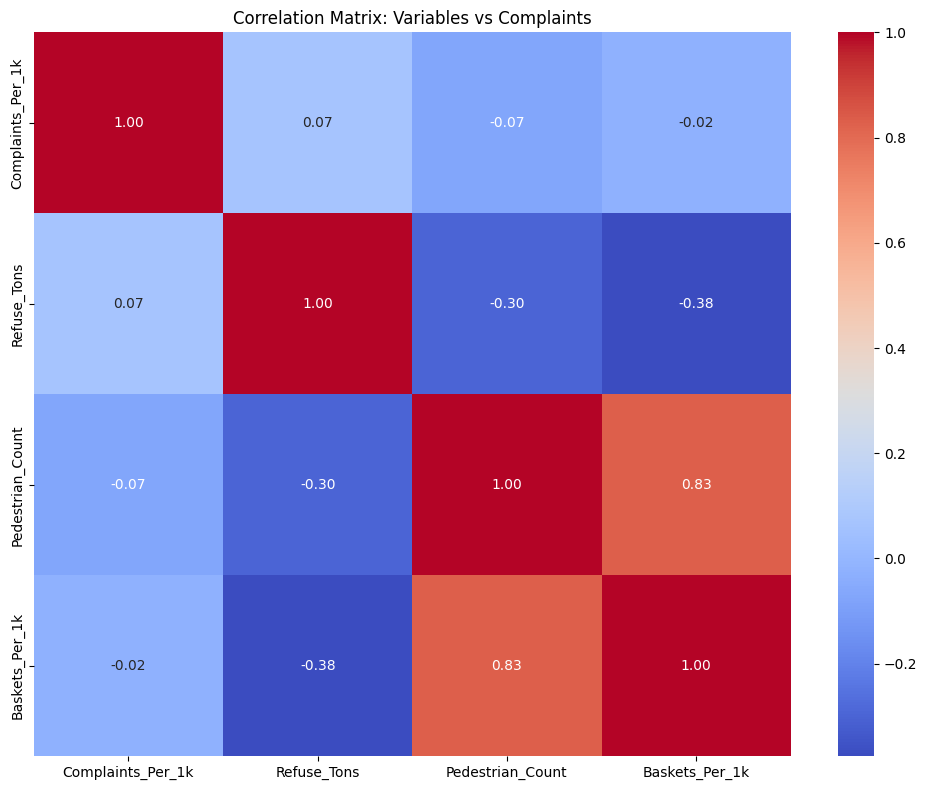

In [71]:
plt.figure(figsize=(10, 8))
corr_cols = ['Complaints_Per_1k', 'Refuse_Tons', 'Pedestrian_Count', 'Baskets_Per_1k']
corr = merged_df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Variables vs Complaints')
plt.tight_layout()
plt.show()

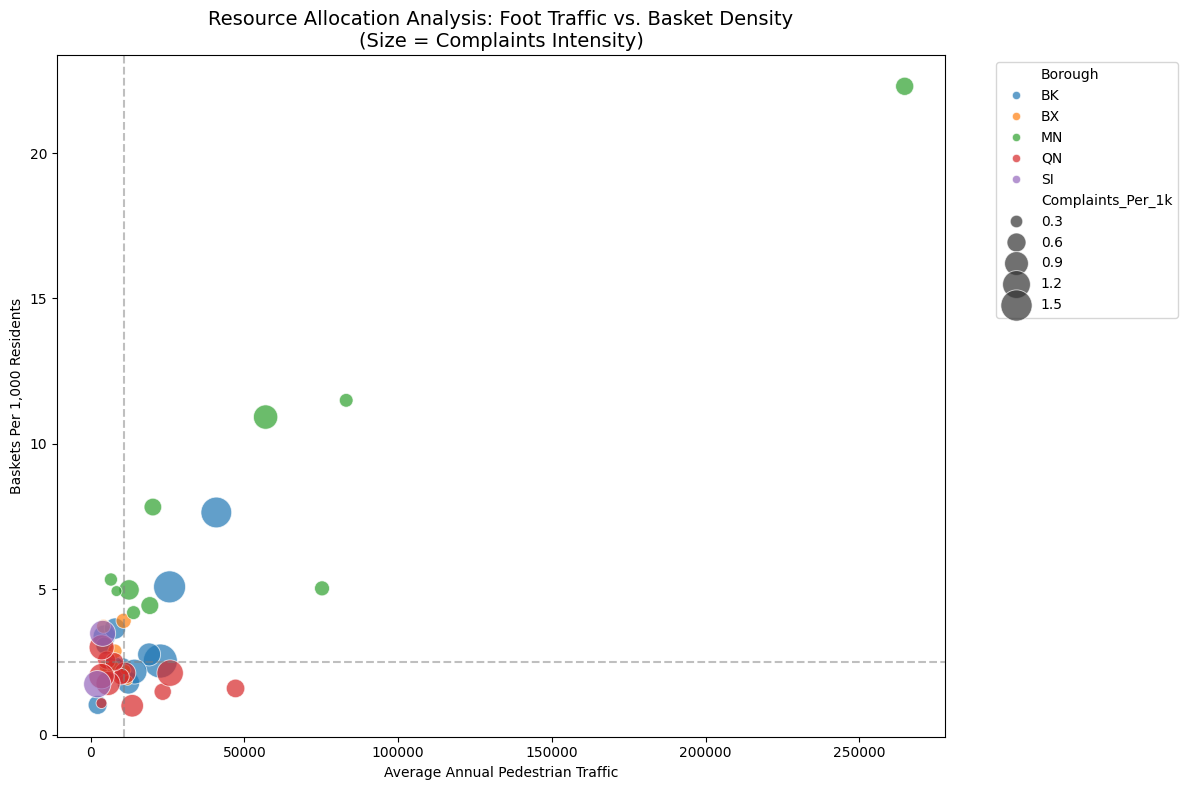

In [ ]:
cd_summary = merged_df[merged_df['year'] == 2023].groupby('CD_ID').agg({
    'Pedestrian_Count': 'mean',
    'Baskets_Per_1k': 'mean',
    'Complaints_Per_1k': 'mean',
}).reset_index()
cd_summary['Borough'] = cd_summary['CD_ID'].str[:2]


plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=cd_summary,
    x='Pedestrian_Count',
    y='Baskets_Per_1k',
    size='Complaints_Per_1k',
    sizes=(50, 600), 
    hue='Borough',
    alpha=0.7,
)

plt.axvline(cd_summary['Pedestrian_Count'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(cd_summary['Baskets_Per_1k'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('Resource Allocation Analysis: Foot Traffic vs. Basket Density\n(Size = Complaints Intensity)', fontsize=14)
plt.xlabel('Average Annual Pedestrian Traffic')
plt.ylabel('Baskets Per 1,000 Residents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

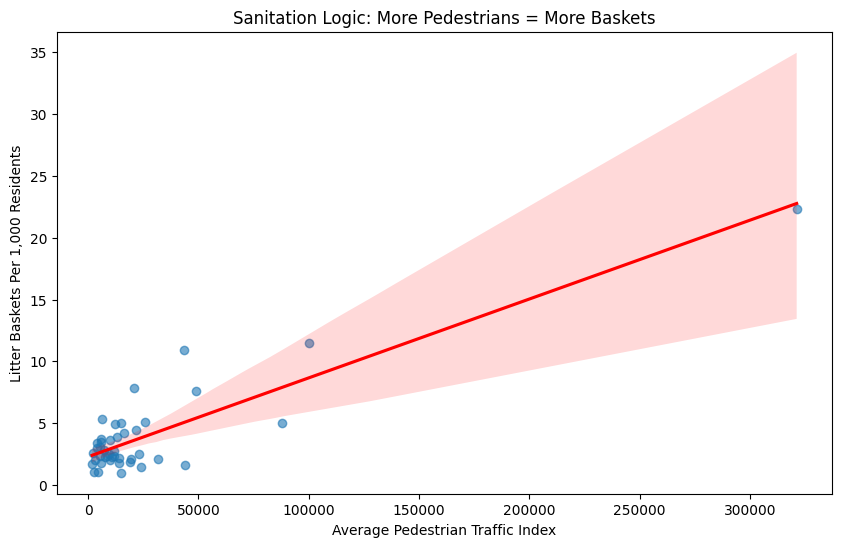

In [75]:
cd_stats = merged_df.groupby('CD_ID')[['Pedestrian_Count', 'Baskets_Per_1k', 'Complaints_Per_1k']].mean().reset_index()
cd_stats['Borough'] = cd_stats['CD_ID'].str[:2]

plt.figure(figsize=(10, 6))
sns.regplot(data=cd_stats, x='Pedestrian_Count', y='Baskets_Per_1k', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Sanitation Logic: More Pedestrians = More Baskets')
plt.xlabel('Average Pedestrian Traffic Index')
plt.ylabel('Litter Baskets Per 1,000 Residents')
plt.show()

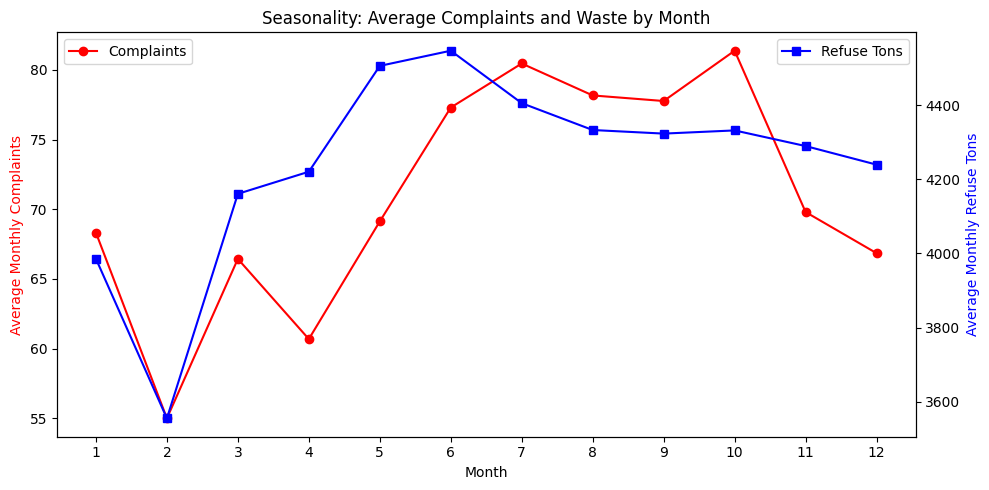

In [ ]:
merged_df['Month_Num'] = pd.to_datetime(merged_df['date']).dt.month
monthly_seasonality = merged_df.groupby('Month_Num')[['Complaints', 'Refuse_Tons']].mean()

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()
monthly_seasonality['Complaints'].plot(ax=ax1, color='red', marker='o', label='Complaints')
monthly_seasonality['Refuse_Tons'].plot(ax=ax2, color='blue', marker='s', label='Refuse Tons')

ax1.set_xlabel('Month')
ax1.set_ylabel('Average Monthly Complaints', color='red')
ax2.set_ylabel('Average Monthly Refuse Tons', color='blue')
plt.title('Seasonality: Average Complaints and Waste by Month')
plt.xticks(range(1, 13))
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

Staten Island Complaint Breakdown:
                        Complaint Type  complaint_count  Percentage
0  Request Large Bulky Item Collection            93213   47.607447
1    Missed Collection (All Materials)            62688   32.017161
2                    Missed Collection            34064   17.397789
3              Litter Basket / Request             2093    1.068975
4           Overflowing Litter Baskets             1385    0.707373
5                Litter Basket Request              790    0.403483
6              Litter Basket Complaint              467    0.238515
7         Request Xmas Tree Collection              451    0.230343
8                       Adopt-A-Basket              198    0.101126
9                  Seasonal Collection              125    0.063842

Rest of NYC Complaint Breakdown:
                        Complaint Type  complaint_count  Percentage
0  Request Large Bulky Item Collection           979199   62.887484
1    Missed Collection (All Materials)         

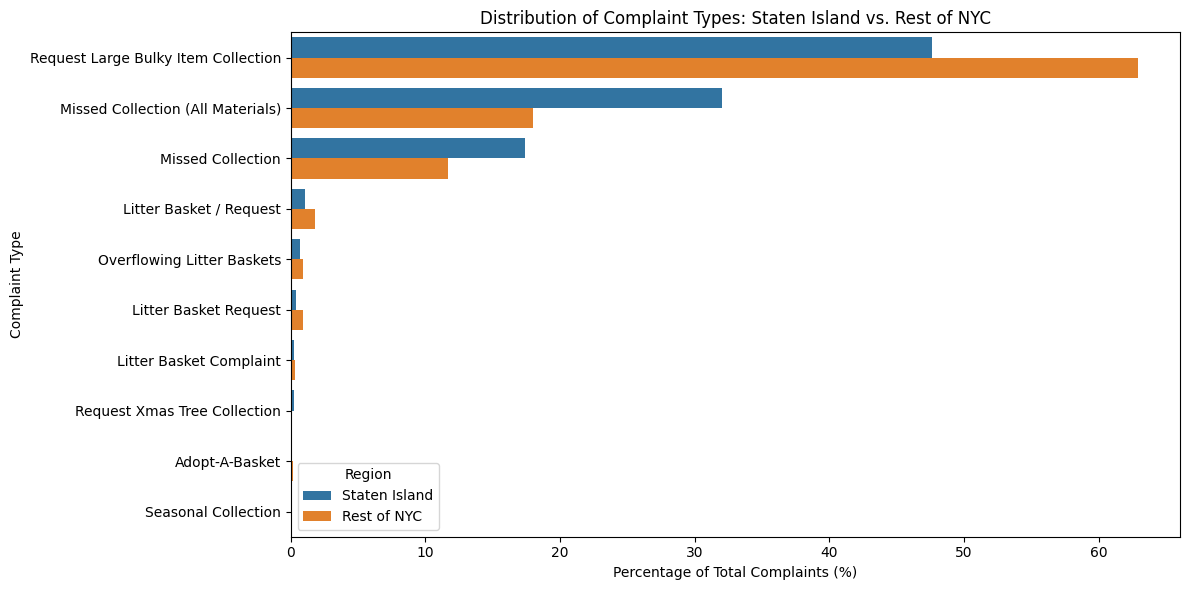

In [ ]:

si_complaints = complaints_df[complaints_df['CD_ID'].str.startswith('SI', na=False)]
rest_nyc_complaints = complaints_df[~complaints_df['CD_ID'].str.startswith('SI', na=False)]

si_counts = si_complaints.groupby('Complaint Type')['complaint_count'].sum().sort_values(ascending=False)
rest_counts = rest_nyc_complaints.groupby('Complaint Type')['complaint_count'].sum().sort_values(ascending=False)

si_df = si_counts.reset_index()
si_df['Region'] = 'Staten Island'
si_df['Percentage'] = si_df['complaint_count'] / si_df['complaint_count'].sum() * 100

rest_df = rest_counts.reset_index()
rest_df['Region'] = 'Rest of NYC'
rest_df['Percentage'] = rest_df['complaint_count'] / rest_df['complaint_count'].sum() * 100

comparison_df = pd.concat([si_df, rest_df])

top_types = si_df['Complaint Type'].head(10).tolist()
comparison_filtered = comparison_df[comparison_df['Complaint Type'].isin(top_types)]

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_filtered, x='Percentage', y='Complaint Type', hue='Region')
plt.title('Distribution of Complaint Types: Staten Island vs. Rest of NYC')
plt.xlabel('Percentage of Total Complaints (%)')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.show()

print("Staten Island Complaint Breakdown:")
print(si_df[['Complaint Type', 'complaint_count', 'Percentage']].head(10))

print("\nRest of NYC Complaint Breakdown:")
print(rest_df[['Complaint Type', 'complaint_count', 'Percentage']].head(10))

In [ ]:
import json
import pandas as pd
import os

output_dir = 'json_exports'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


def clean_data(df):
    return df.fillna(0)


seasonality_clean = clean_data(monthly_seasonality.reset_index())
seasonality_export = seasonality_clean.to_dict(orient='records')
print(seasonality_export)

scatter_df = cd_summary[['CD_ID', 'Pedestrian_Count', 'Baskets_Per_1k', 'Complaints_Per_1k', 'Borough']]
scatter_clean = clean_data(scatter_df)
scatter_export = scatter_clean.to_dict(orient='records')

top_types_list = si_df.sort_values('Percentage', ascending=False)['Complaint Type'].head(10).tolist()
si_dict = si_df.set_index('Complaint Type')['Percentage'].to_dict()
rest_dict = rest_df.set_index('Complaint Type')['Percentage'].to_dict()

comparison_export = []
for c_type in top_types_list:
    val_si = si_dict.get(c_type, 0)
    val_rest = rest_dict.get(c_type, 0)
    
    if pd.isna(val_si): val_si = 0
    if pd.isna(val_rest): val_rest = 0
    
    comparison_export.append({
        "type": c_type,
        "Staten Island": round(val_si, 2),
        "Rest of NYC": round(val_rest, 2)
    })

corr_export = []
corr_clean = corr.fillna(0) 

for row_name in corr_clean.index:
    for col_name in corr_clean.columns:
        val = corr_clean.loc[row_name, col_name]
        corr_export.append({
            "x": col_name,
            "y": row_name,
            "value": round(val, 4)
        })

final_data = {
    "seasonality": seasonality_export,
    "scatter": scatter_export,
    "siComparison": comparison_export,
    "correlation": corr_export
}

output_path = f'{output_dir}/analysis_data.json'
with open(output_path, 'w') as f:
    json.dump(final_data, f, allow_nan=False)

print(f"Save : {output_path}")